# Transcriptor factor

In [67]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd
from anndata import AnnData

In [68]:
experiment = "RNAseq_abundances_adjusted_combat_inmose"
comparison = 'middle.vs.old'

In [69]:
tf_df = pd.read_csv(f'results/tf_acts{experiment}_{comparison}.csv', index_col=0)
tf_df

,middle.vs.old,pvals
ABL1,-0.533107,0.593964
AHR,-1.837573,0.066137
AHRR,-0.599503,0.548843
AIP,1.572328,0.115887
AIRE,0.351229,0.725420
...,...,...
ZNF699,0.292141,0.770182
ZNF76,0.640774,0.521675
ZNF804A,-0.358295,0.720126
ZNF91,0.276512,0.782157


In [70]:
tf_df = tf_df[tf_df['pvals']<0.1]
tf_acts=pd.DataFrame(tf_df[comparison])
tf_acts=tf_acts.T
tf_acts

,AHR,BHLHA15,CEBPA,CEBPB,CREBZF,CTBP1,CTCFL,CTNNB1,CUX1,DAXX,...,TCF3,TCF7,TLX3,USF2,VDR,VEZF1,ZBTB4,ZBTB7B,ZFPM1,ZGPAT
middle.vs.old,-1.837573,-2.011781,-2.779439,-2.152929,-1.702532,1.905893,-1.977108,-3.193939,-1.735158,-1.765442,...,-1.748946,-1.834114,-2.414947,2.098204,-2.393092,1.743533,2.286686,-1.689793,-2.443139,-2.770551


In [71]:
values = tf_acts.iloc[0]
values

AHR       -1.837573
BHLHA15   -2.011781
CEBPA     -2.779439
CEBPB     -2.152929
CREBZF    -1.702532
             ...   
VEZF1      1.743533
ZBTB4      2.286686
ZBTB7B    -1.689793
ZFPM1     -2.443139
ZGPAT     -2.770551
Name: middle.vs.old, Length: 97, dtype: float64

In [72]:
down_reg = values.sort_values(ascending=True)[:5].index.to_list()
up_reg = values.sort_values(ascending=False)[:5].index.to_list()
up_down_reg = down_reg.copy()
up_down_reg.extend(up_reg)
up_down_reg

['SALL3',
 'LRRFIP1',
 'CTNNB1',
 'SF1',
 'SP1',
 'OLIG2',
 'POU2F3',
 'FOXL2',
 'ZBTB4',
 'NR2F6']

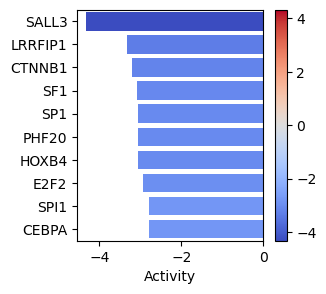

In [73]:
dc.plot_barplot(
    acts=tf_acts,
    contrast=comparison,
    top=10,
    vertical=True,
    figsize=(3, 3)
)

In [74]:
def plot_personalize_bars(tf_df, title="", top=20, 
                          lFCs_thr=0.5, sig_thr=0.05,
                          sig = 'padj', title_fontsize=14, 
                          figsize=(5, 5), vertical=True):
    # Generate the volcano plot
    fig = dc.plot_barplot(
        acts=tf_df,
        contrast=comparison,
        top=top,
        vertical=True,
        figsize=figsize,
        dpi=100,
        return_fig=True
    )
    
    # Access the Axes object from the figure
    ax = fig.gca()
    
    # Add a title and remove the outer black line
    ax.set_title(title, fontsize=title_fontsize)
    for spine in ax.spines.values():
        spine.set_visible(False)  # Hide all outer spines
    
    return fig, ax

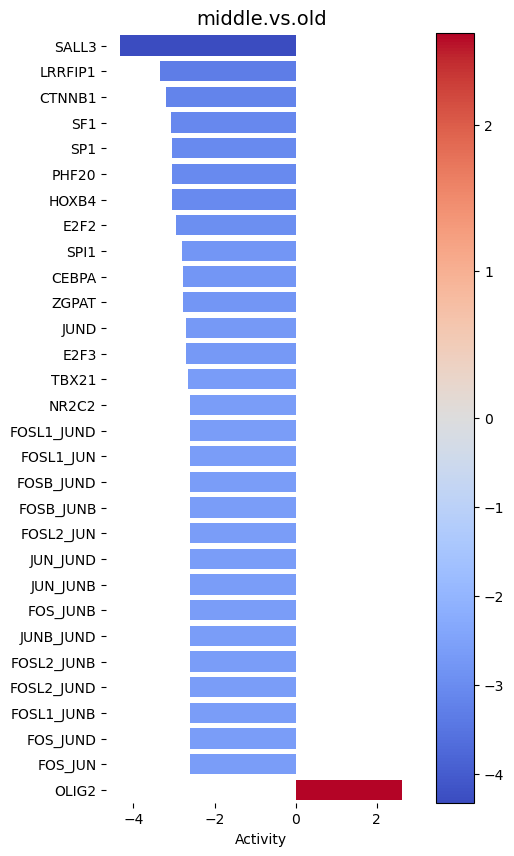

In [75]:
fig, ax = plot_personalize_bars(tf_acts, title=comparison, top=30, figsize=(5, 10))

In [76]:
fig.savefig(f"results/{experiment}_{comparison}_TF_Bar.png", bbox_inches='tight')


In [77]:
comparison

'middle.vs.old'